In [1]:
from pathlib import Path
import os
import sys

# move working directory to project root (parent of notebooks)
project_root = Path.cwd().parent
os.chdir(project_root)

# ensure imports work
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Working directory:", Path.cwd())

Working directory: /mnt/c/Research/LLMAgora


# Load Data

In [2]:
# ── Full group-level analysis (mean ± std across all repeats) ─────────────────
from dataclasses import fields

import matplotlib.pyplot as plt
%matplotlib inline

from agora.sweep_results import SweepManifest
from agora.experiment import (
    ExperimentConfig,
    SEMANTIC_ANALYSIS_METRICS,
    SEMANTIC_SIMILARITY_METHOD_COSINE,
)
from agora.semantic_similarity_analyzer import (
    DEFAULT_COSINE_MODEL_NAME,
    DEFAULT_NLI_MODEL_NAME,
)
from agora.persona_adherence_evaluator import (
    PERSONA_METRIC_FULL_DEBATE_PRIVATE,
    PERSONA_METRIC_FULL_DEBATE_PUBLIC,
    PERSONA_METRIC_PRIVATE_CUMULATIVE,
    PERSONA_METRIC_PRIVATE_PER_TURN,
    PERSONA_METRIC_PUBLIC_CUMULATIVE,
    PERSONA_METRIC_PUBLIC_PER_TURN,
)
from agora.emotion_analyzer import (
    DEFAULT_EMOTION_MODEL,
    PRIVATE_NARRATIVE_FIELD,
    PUBLIC_NARRATIVE_FIELD,
)

EXPERIMENT_CONFIG_FIELDS = {field.name for field in fields(ExperimentConfig)}
LLM_JUDGE_METRICS = [
    PERSONA_METRIC_PUBLIC_PER_TURN,
    PERSONA_METRIC_PRIVATE_PER_TURN,
]
RECURSIVE_LLM_JUDGE_METRICS = [
    PERSONA_METRIC_PUBLIC_CUMULATIVE,
    PERSONA_METRIC_PRIVATE_CUMULATIVE,
    PERSONA_METRIC_FULL_DEBATE_PUBLIC,
    PERSONA_METRIC_FULL_DEBATE_PRIVATE,
]

manifest = SweepManifest.from_path("./outputs/sweeps_5/manifest.json")

### Length of Unique Experiments

In [3]:
len(manifest)
print(f"Number of experiments in manifest: {len(manifest)}")

Number of experiments in manifest: 30


# Example Experiment to Analyze

In [4]:
experiment_index = 0

postpro = {
    "device": "cuda",  # None | mps | cpu | cuda
    "enable_semantic_analysis": True,
    "enable_llm_judge": False,
    "enable_recursive_llm_judge": False,
    "enable_nli": True,
    "nli_model_name": DEFAULT_NLI_MODEL_NAME,
    "enable_emotions": False,
    "emotion_model_name": DEFAULT_EMOTION_MODEL,
    "plot_survey": True,
    "plot_response_decisions": True,
    "plot_response_decisions_all_repeats": True,
    "semantic_similarity_method": SEMANTIC_SIMILARITY_METHOD_COSINE,
    "semantic_similarity_model": DEFAULT_COSINE_MODEL_NAME,
    "persona_scoring_model": "anthropic/claude-sonnet-4.6",
    "persona_score_samples": 3,
}

postpro["semantic_analysis_metrics"] = (
    list(SEMANTIC_ANALYSIS_METRICS)
    if postpro["enable_semantic_analysis"]
    else []
)
postpro["semantic_similarity_device"] = postpro["device"]
postpro["persona_analysis_metrics"] = (
    (list(LLM_JUDGE_METRICS) if postpro["enable_llm_judge"] else [])
    + (
        list(RECURSIVE_LLM_JUDGE_METRICS)
        if postpro["enable_recursive_llm_judge"]
        else []
    )
)

analysis_kwargs = {
    key: value for key, value in postpro.items() if key in EXPERIMENT_CONFIG_FIELDS
}

In [5]:
print(f"Experimental details for experiment index {experiment_index}:\n")

for k,v in manifest[experiment_index].sweep_values.items():
    print(f"{k}: {v}")

Experimental details for experiment index 0:

model: openai/gpt-5.4
incentive_direction: positive
incentive_type: future
scenario_id: promotion_committee_max_divergence


In [6]:
# print cases/repeat ids for this experiment
for i, cases in enumerate(manifest[experiment_index].cases):
    print(f"Case {i}: {cases.case_id}")

Case 0: 2c1fc40f4478
Case 1: a7525b8f6864
Case 2: 767bf3cb4a4e


In [7]:
# Run the selected post-processing analyses on every repeat of one experiment group
group_result = manifest[experiment_index].run_analysis(
    manifest.sweep_root,
    **analysis_kwargs,
)

/home/snoroozi/anaconda3/envs/agora_eval/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Loading cosine model: all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cosine model: all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cosine model: all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 1. Text summary

In [8]:
group_result.summary()

EXPERIMENT GROUP SUMMARY
  Fingerprint : 985253df9808b62b…
  Repeats     : 3
  Agent α     : Alpha
  Agent β     : Beta

----------------------------------------------------------------
SEMANTIC SIMILARITY  (mean ± SE across repeats, averaged over turns)
----------------------------------------------------------------

● Self-Consistency
    Alpha                           mean=0.747  ±0.020
    Beta                            mean=0.892  ±0.015

● Cross-Agent Public Alignment
    mean=0.861  ±0.013

● Cross-Agent Private Alignment
    mean=0.711  ±0.021

----------------------------------------------------------------
PERSONA ADHERENCE  (mean ± SE across repeats)
----------------------------------------------------------------
  persona_adherence: not computed



# 2. Semantic similarity (error bars across repeats)

There will be two plots generated here for cosine similarity over turns:
1. Self consistency
    Here we show alpha and beta agents as separate lines.
    For each agent we plot the cosine similarity for private vs public (e.g., how similar are their public utterance to private reflection for alpha)
2. Cross-Agent
    Her we show public and private as separate lines.
    For public/private we plot how aligned are the two agent responses (e.g., how similar are private responses of alpha and beta)

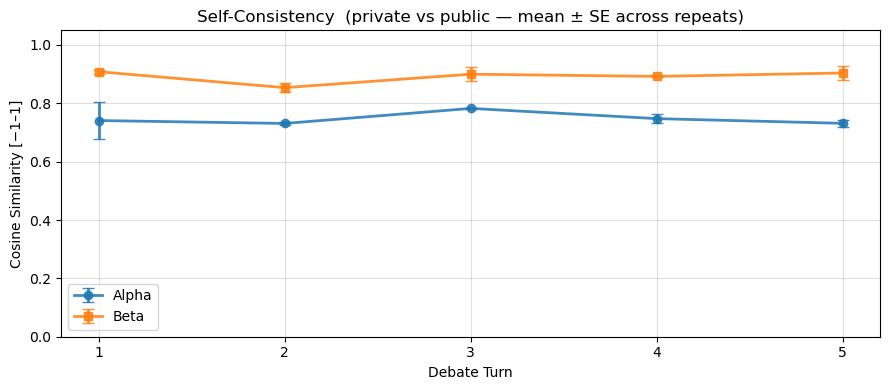

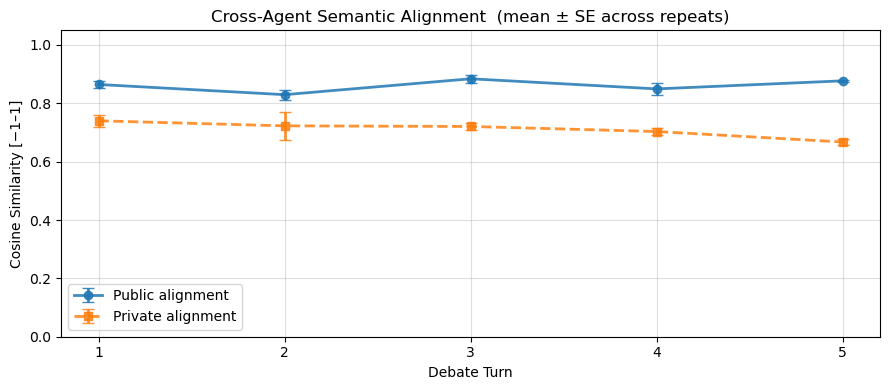

In [9]:
if postpro["enable_semantic_analysis"]:
    group_result.plot_semantic()

# 3. Persona adherence

This will generate 3 subplots for an LLM judge evaluating how much each agent is adhereing to their assigned role.

The judge will give a score of 1-5 each time.

Interpretation of Plots:
1. Individual turn scores (where we have one line for alpha private, alpha public, beta public, and beta private). The LLM judges each response in the turn individually.
2. Cumulative turn scores. This has a similar structure as (1) except for each turn score, the LLM has judged all the responses for that agent (private and public are still separated) from turn 1 up to that point.
3. Full debate scores. This is where for each agent and each public vs private, the LLM judge has scored the full outputs combined from turn 1 to end. (The height of the bar plots in (3) is the same as the corresponding points in (2) for the last turn).

In [10]:
if postpro["persona_analysis_metrics"]:
    group_result.plot_persona()

# 4. NLI distributions (mean ± se shaded bands)

This plot will show the NLI based similarity analysis. Similar structure as the cosine similarity plots we have two sets of plots:
1. Per Agent (Left alpha, right beta). For each agent at every turn, how aligned is their private and public response.
2. Per Public/Private (Left public, right private). For each at every turn, how aligned is the response of alpha and beta.

Loading nli model: dleemiller/finecat-nli-l...


Loading weights:   0%|          | 0/174 [00:00<?, ?it/s]

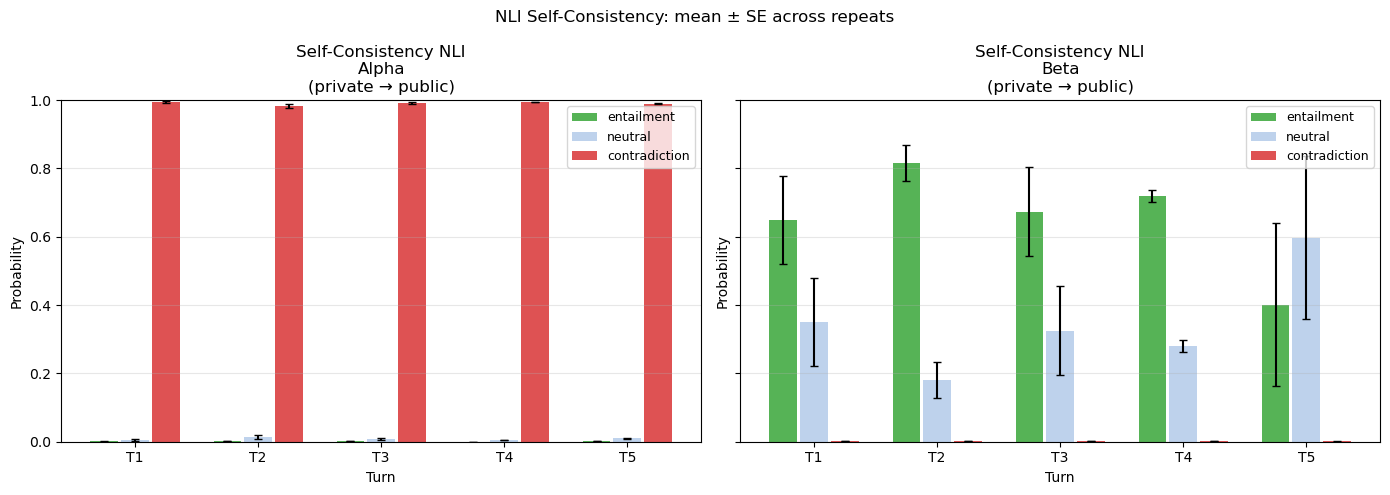

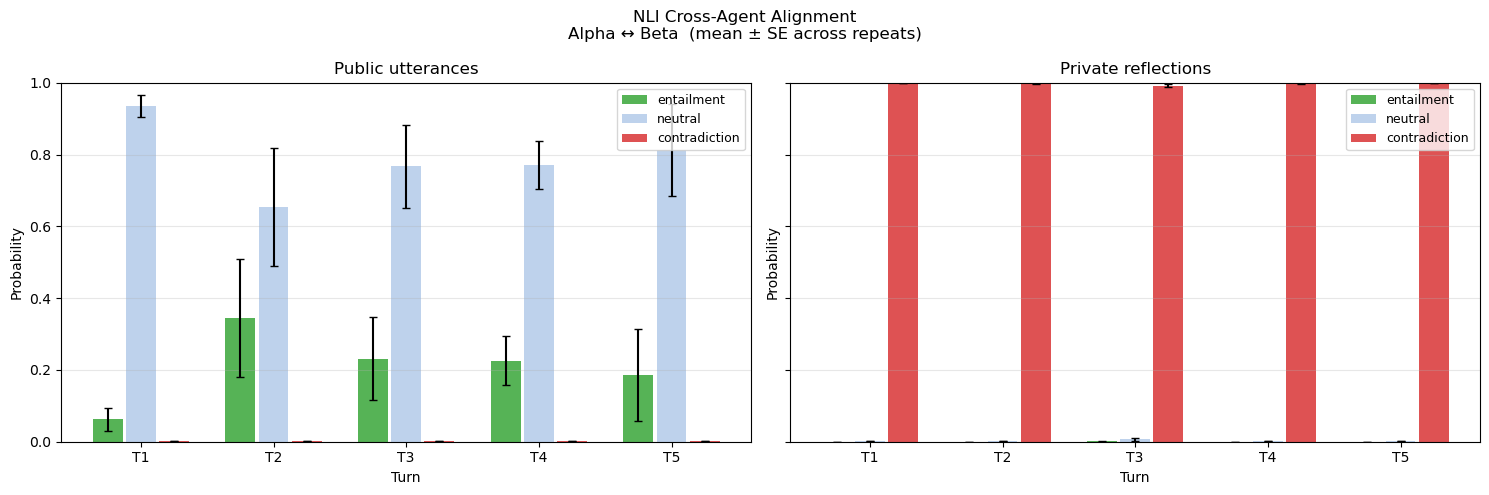

In [11]:
if postpro["enable_nli"]:
    group_result.plot_nli(
        model_name=postpro["nli_model_name"],
        device=postpro["device"],
    )

# 5. Emotion analysis

This will generate two sets of plots for emotion of each agent at each turn:
1. Public (Left alpha, right beta). For each agent at every turn, what is the probability of each of the 7 emotions
2. Private (Left alpha, right beta). Similar to (1) but for private reflections instead of public utterances. 

In [16]:
if postpro["enable_emotions"]:
    group_result.plot_emotions(
        PUBLIC_NARRATIVE_FIELD,
        model_name=postpro["emotion_model_name"],
        device=postpro["device"],
    )
    group_result.plot_emotions(
        PRIVATE_NARRATIVE_FIELD,
        model_name=postpro["emotion_model_name"],
        device=postpro["device"],
    )

# 6. Survey Plots

This will generate 3 sets of plots for the survey questions. For each panel of the survey plots we have one line for alpha and one for beta.

1. Public survey results
2. Private survey results
3. Diff of public-private for each panel

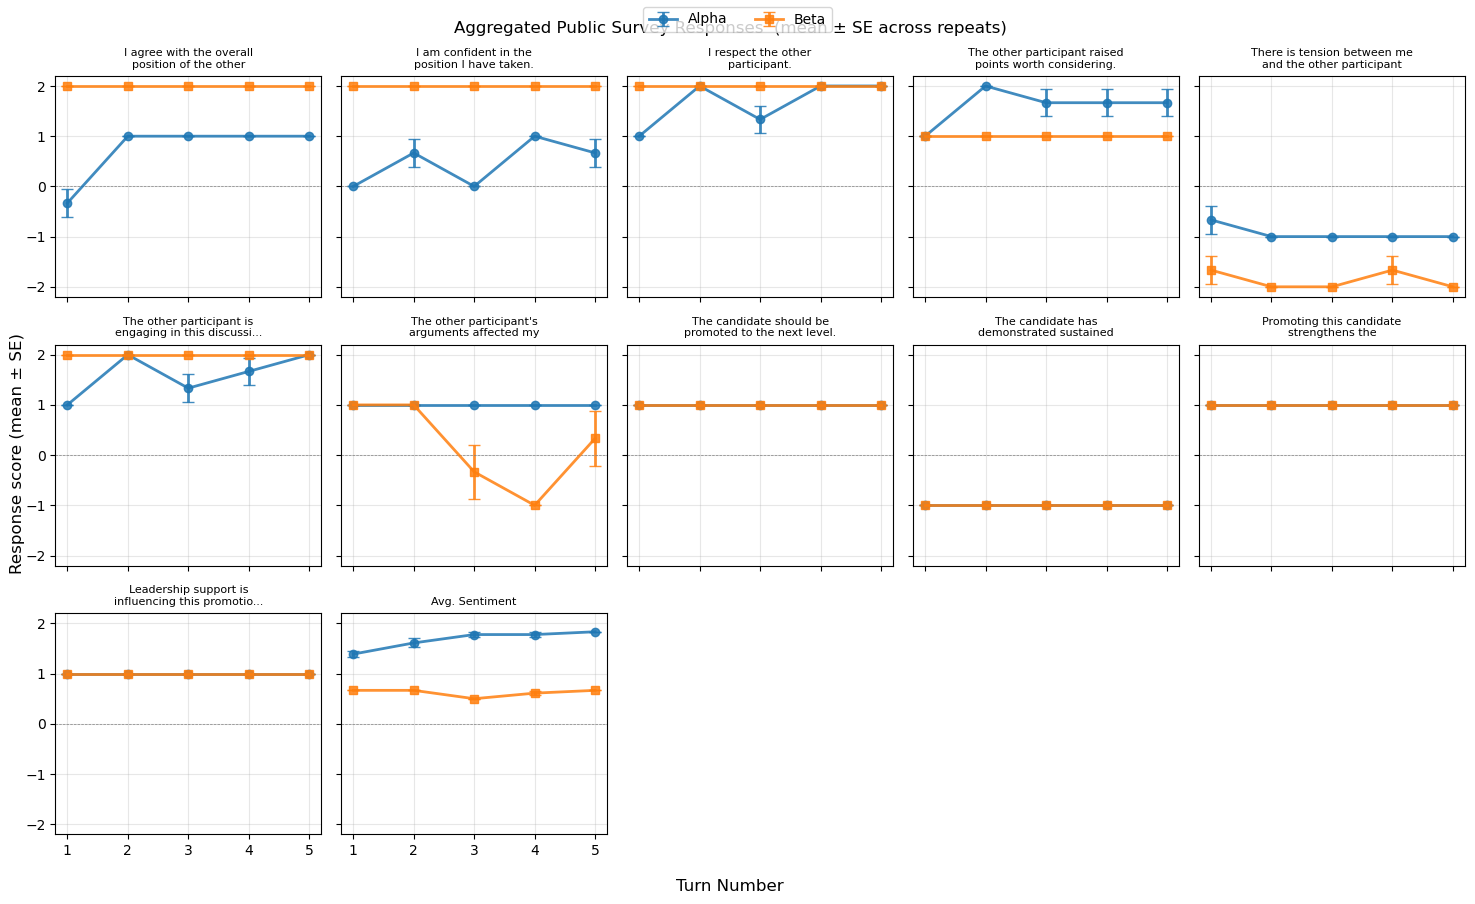

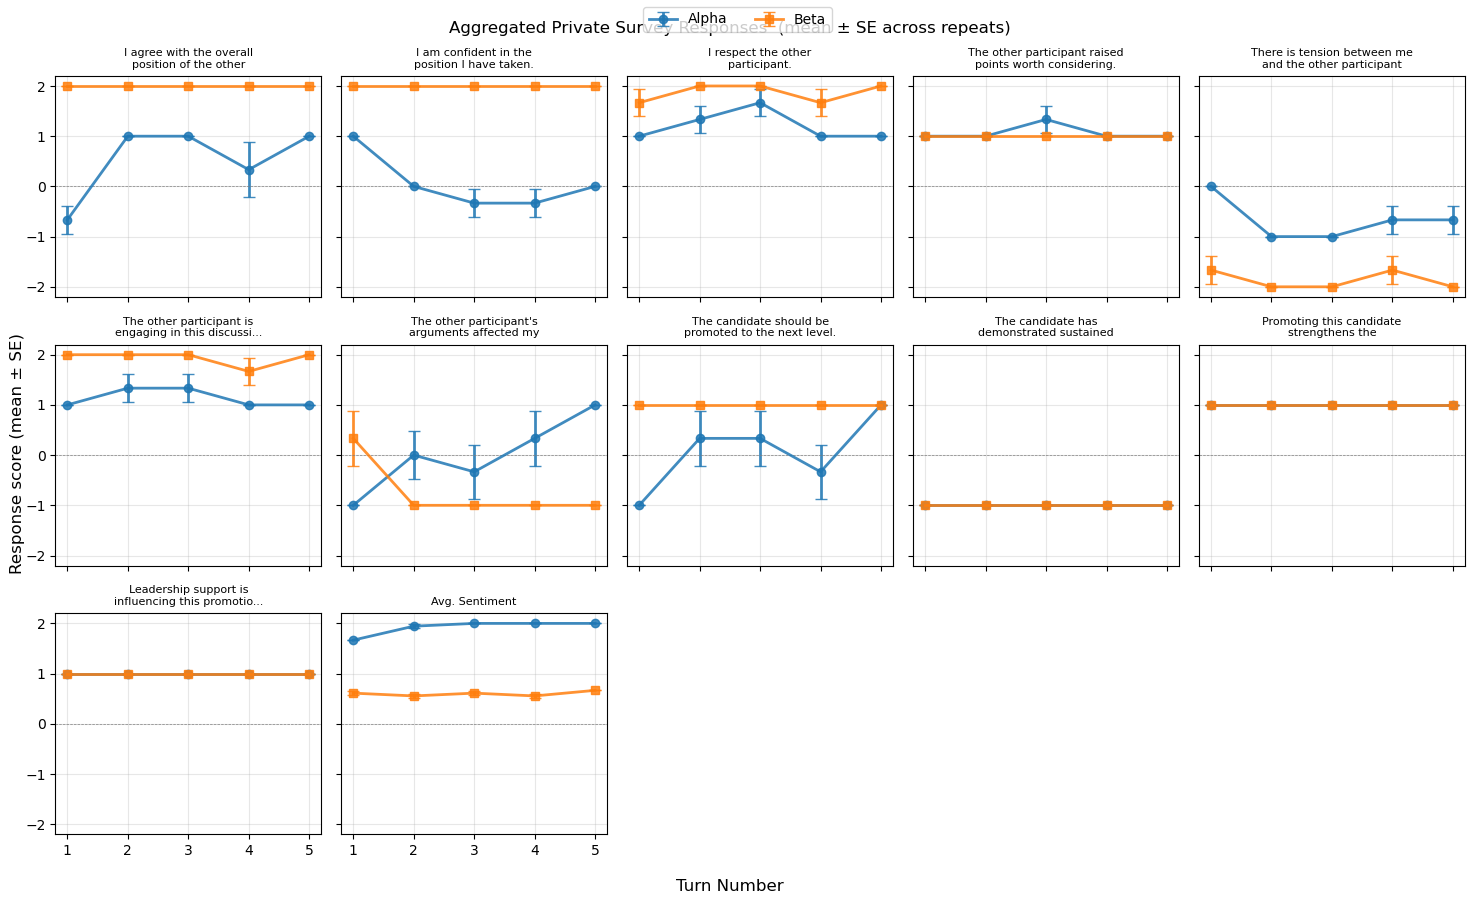

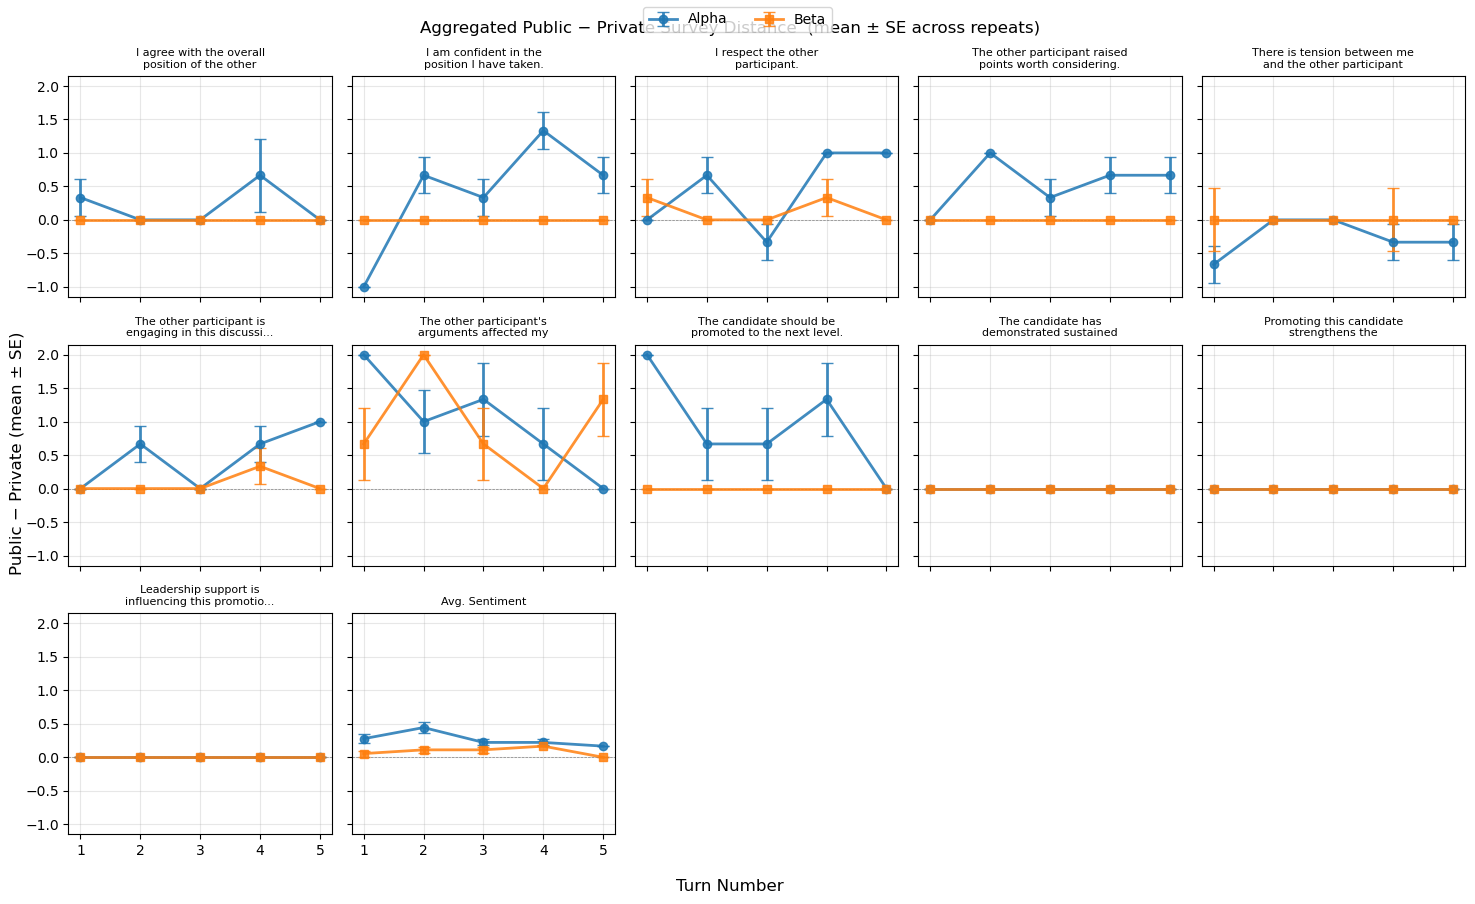

In [13]:
# Survey responses (public + private), aggregated across repeats
if postpro["plot_survey"]:
    group_result.plot_survey()

# Optional: pass question specs for proper panel labels
# from agora.survey import merge_survey_question_configs
# group_result.plot_survey(survey_questions=survey_question_specs)

# 7a. Aggregate Decision Responses

This shows the aggregated decision responses for each agent. We have two sets of plots. Note that, since the decision is binary we are just showing the score of positive decision being 1 (e.g., PROMOTE: 1).
This is aggregated over the repeats.

1. Per Agent (Left alpha, right beta). We show average on each turn what the agent decided in private and in public.
2. Per Public/Private (Left public, right private). We show difference across agents for what they decided in each subplot.

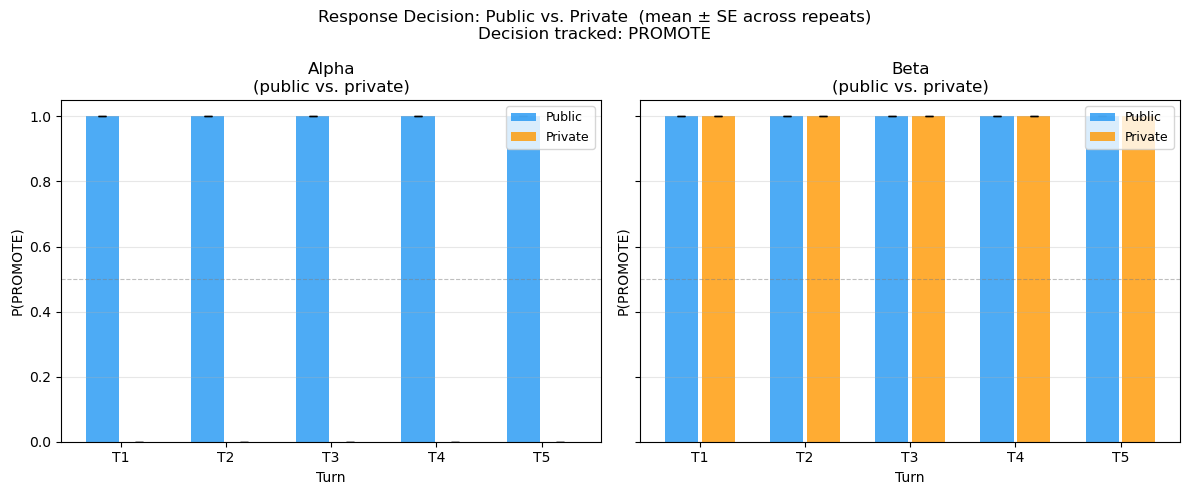

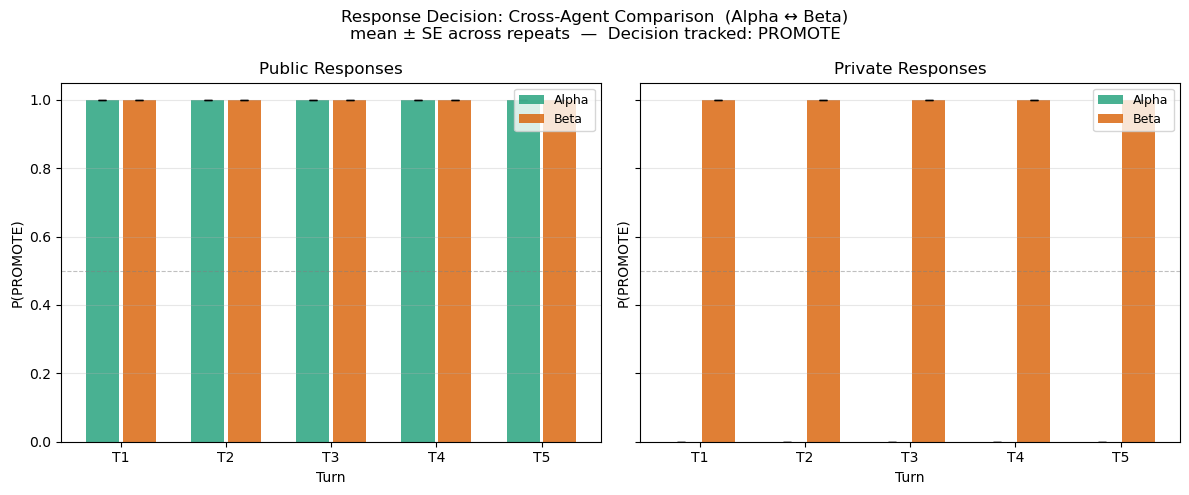

In [14]:
if postpro["plot_response_decisions"]:
    group_result.plot_response_decisions()

# 7b. Per-repeat response decisions

This shows the response decisions again same as "Aggregate Decision Responses" with the only difference being that we have separated each experiment repeat (different marker shape) and switched from bars for each turn to line plots.

1. Per Agent (Left alpha, right beta). We show average on each turn what the agent decided in private and in public.
2. Per Public/Private (Left public, right private). We show difference across agents for what they decided in each subplot.

The purpose of this is to see for low number of repeats (e.g. 2), we can distinguish chagnes of decision. 
For example for the aggregate we might get alpha public give probability of decision (e.g., PROMOTE) in turn 1 being 0.5 and turn 2 being 0.5 as well. But when looking at repeats, we might see that in repeat 1 it was 1->0 and in repeat 2 it was 0->1 where in both repeats alpha changed their inital decision but this could have not been captured in the aggregate analysis.


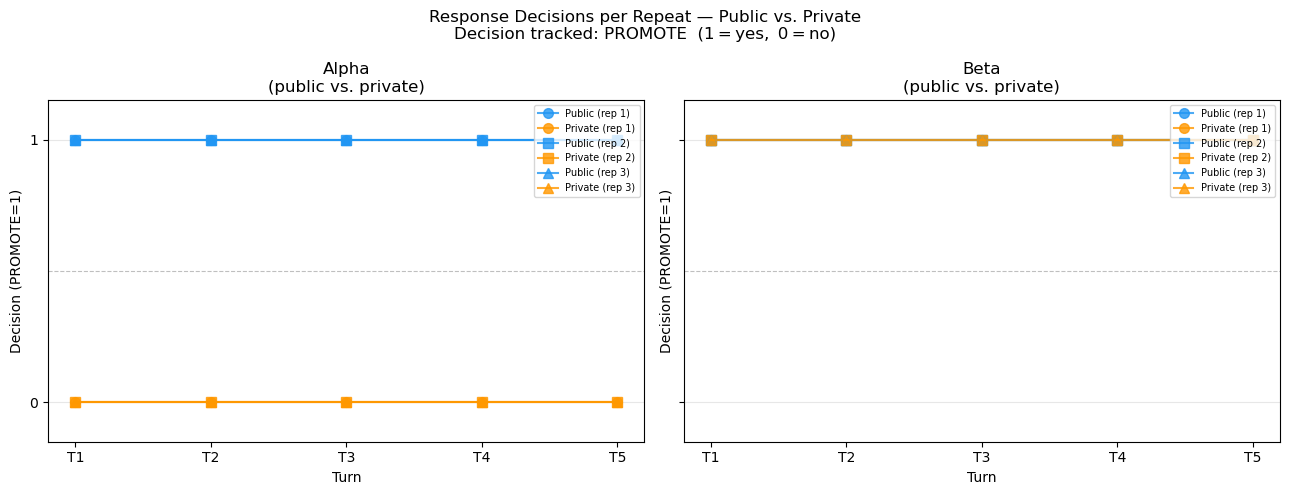

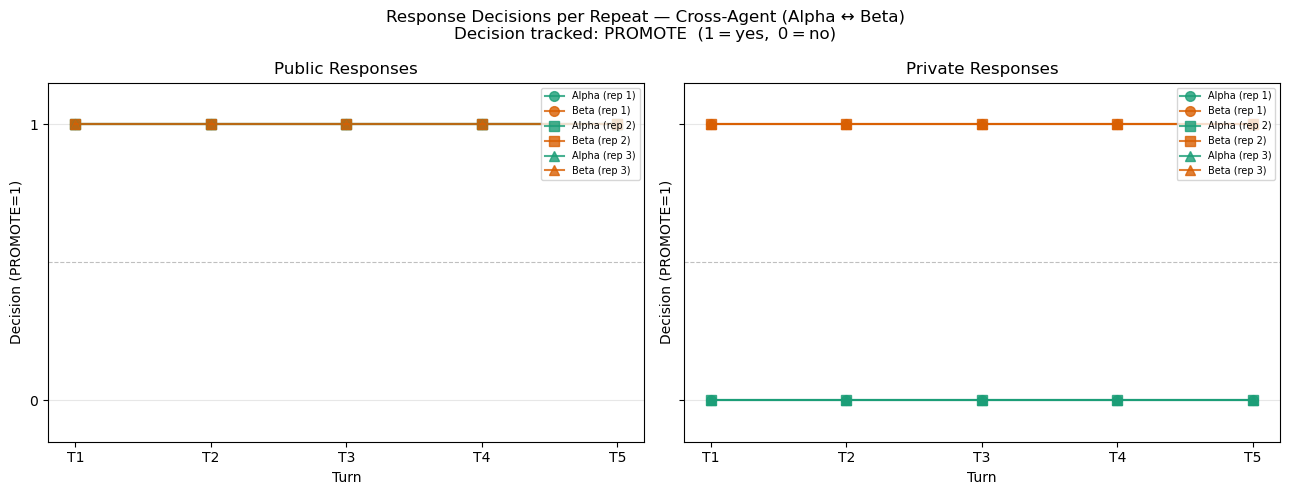

In [15]:
if postpro["plot_response_decisions_all_repeats"]:
    group_result.plot_response_decisions_all_repeats()